<a href="https://colab.research.google.com/github/natrask/ENM5320-2026/blob/main/NewMaterial/Lecture18_Apr15/SDE_HarmonicOscillator_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural SDE: Learning a Stochastic Harmonic Oscillator from Data

We consider a damped harmonic oscillator driven by thermal (white) noise:

$$\ddot{\theta} = -mg\,\theta - \beta\,\dot{\theta} + \alpha\,\frac{dW_t}{dt}$$

Rewriting as a first-order Itô SDE with state $\mathbf{X} = (\theta,\;\omega)$ where $\omega = \dot{\theta}$:

$$d\theta = \omega\,dt, \qquad d\omega = \underbrace{(-mg\,\theta - \beta\,\omega)}_{\text{drift}} dt + \underbrace{\alpha}_{\text{diffusion}}\,dW_t$$

**Goal:** Given trajectory data from this SDE, learn a neural model of the form

$$d\omega = n_1(\theta,\omega)\,dt + n_2(\theta)\,dW_t$$

by discretizing with **Euler–Maruyama**, obtaining a **Gaussian transition density**, and maximizing the **log-likelihood** under a **Markov assumption**.

## 1. Import Required Libraries

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Define the True SDE Parameters and Simulate Synthetic Data

We set the physical parameters and generate trajectory data by solving the SDE with Euler–Maruyama.

**True dynamics** (first-order system, $\omega = \dot\theta$):

$$\theta_{n+1} = \theta_n + \omega_n\,\Delta t$$
$$\omega_{n+1} = \omega_n + (-mg\,\theta_n - \beta\,\omega_n)\,\Delta t + \alpha\,\sqrt{\Delta t}\;\xi_n, \qquad \xi_n \sim \mathcal{N}(0,1)$$

In [2]:
# ── True physical parameters ──
mg    = 5.0    # effective gravitational restoring (mg/L for a pendulum)
beta  = 0.5    # damping coefficient
alpha = 0.5    # noise intensity

# ── Simulation settings ──
dt      = 0.01
T       = 10.0
N_steps = int(T / dt)
N_traj  = 64   # number of independent realisations

# ── Euler–Maruyama integration ──
theta = np.zeros((N_traj, N_steps + 1))
omega = np.zeros((N_traj, N_steps + 1))

# Random initial conditions (small perturbations)
theta[:, 0] = np.random.randn(N_traj) * 0.5
omega[:, 0] = np.random.randn(N_traj) * 0.1

for n in range(N_steps):
    xi = np.random.randn(N_traj)                       # iid standard normal
    theta[:, n+1] = theta[:, n] + omega[:, n] * dt
    omega[:, n+1] = (omega[:, n]
                     + (-mg * theta[:, n] - beta * omega[:, n]) * dt
                     + alpha * np.sqrt(dt) * xi)

t_grid = np.linspace(0, T, N_steps + 1)
print(f"Generated {N_traj} trajectories, each with {N_steps} time-steps (dt={dt})")
print(f"True parameters:  mg = {mg},  β = {beta},  α = {alpha}")

Generated 64 trajectories, each with 1000 time-steps (dt=0.01)
True parameters:  mg = 5.0,  β = 0.5,  α = 0.5


## 3. Visualize the Synthetic Trajectory

We plot a few sample trajectories and the phase portrait to confirm the characteristic damped-oscillator-plus-noise behavior.

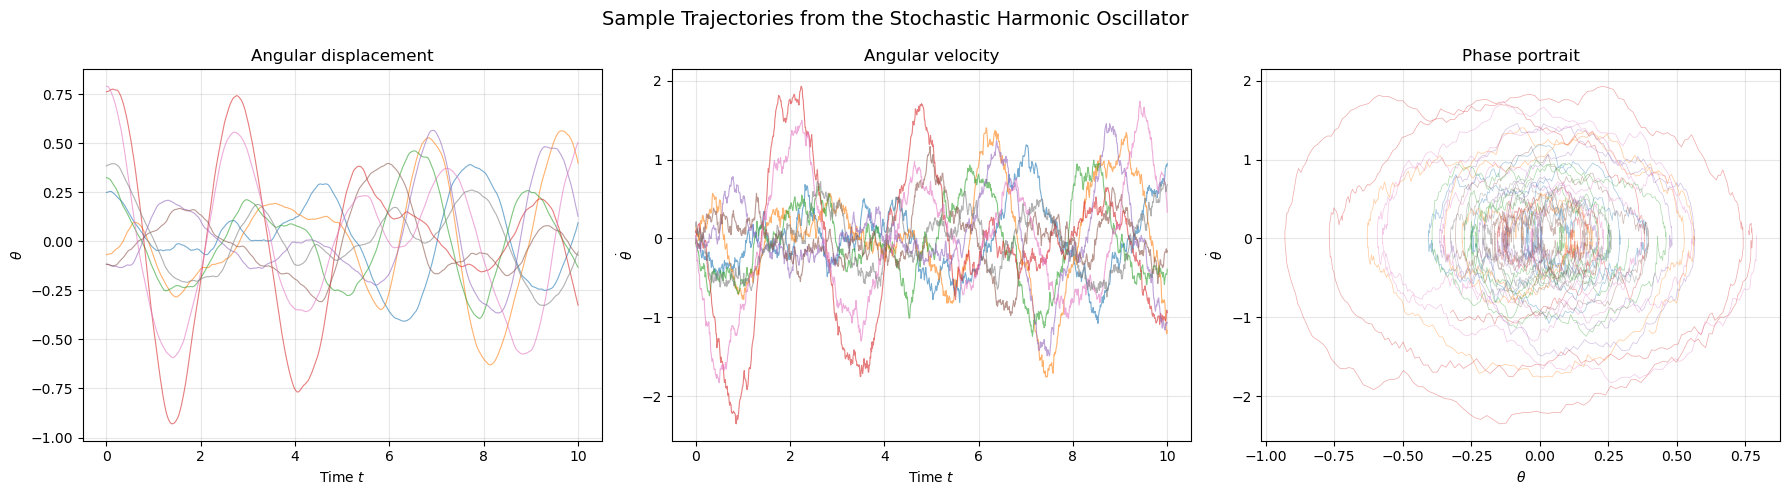

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) θ(t)
for i in range(min(8, N_traj)):
    axes[0].plot(t_grid, theta[i], alpha=0.6, linewidth=0.8)
axes[0].set_xlabel("Time $t$")
axes[0].set_ylabel(r"$\theta$")
axes[0].set_title("Angular displacement")
axes[0].grid(True, alpha=0.3)

# (b) ω(t)
for i in range(min(8, N_traj)):
    axes[1].plot(t_grid, omega[i], alpha=0.6, linewidth=0.8)
axes[1].set_xlabel("Time $t$")
axes[1].set_ylabel(r"$\dot{\theta}$")
axes[1].set_title("Angular velocity")
axes[1].grid(True, alpha=0.3)

# (c) Phase portrait
for i in range(min(8, N_traj)):
    axes[2].plot(theta[i], omega[i], alpha=0.4, linewidth=0.5)
axes[2].set_xlabel(r"$\theta$")
axes[2].set_ylabel(r"$\dot{\theta}$")
axes[2].set_title("Phase portrait")
axes[2].grid(True, alpha=0.3)

plt.suptitle("Sample Trajectories from the Stochastic Harmonic Oscillator", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Euler–Maruyama Discretization and Gaussian Transition Density

Under the Euler–Maruyama scheme with learned drift $n_1$ and diffusion $n_2$:

$$\theta_{n+1} = \theta_n + \omega_n\,\Delta t \qquad\text{(deterministic, given state)}$$
$$\omega_{n+1} = \omega_n + n_1(\theta_n, \omega_n)\,\Delta t + n_2(\theta_n)\,\sqrt{\Delta t}\;\xi_n$$

Since $\xi_n\sim\mathcal{N}(0,1)$, the **transition density** is Gaussian:

$$p\!\left(\omega_{n+1}\mid \theta_n, \omega_n\right) = \mathcal{N}\!\left(\;\underbrace{\omega_n + n_1(\theta_n,\omega_n)\,\Delta t}_{\mu_n},\;\;\underbrace{n_2(\theta_n)^2\,\Delta t}_{\sigma_n^2}\;\right)$$

We define a helper that computes $\log p$ for a batch of transitions.

In [4]:
def gaussian_log_prob(omega_next, mu, sigma_sq):
    """
    Log-density of N(omega_next ; mu, sigma_sq) for each element.
    Returns a tensor of per-sample log-probabilities.
    """
    return -0.5 * (torch.log(2 * np.pi * sigma_sq)
                   + (omega_next - mu) ** 2 / sigma_sq)

## 5. Build Neural Network Models for Drift and Diffusion

| Network | Input | Output | True target |
|---------|-------|--------|-------------|
| $n_1(\theta,\omega)$ | $(\theta,\omega)\in\mathbb{R}^2$ | acceleration $\in\mathbb{R}$ | $-mg\,\theta - \beta\,\omega$ |
| $n_2(\theta)$ | $\theta\in\mathbb{R}$ | diffusion coeff $\in\mathbb{R}^+$ | $\alpha$ (constant) |

Both are small MLPs with `Tanh` activations.  The diffusion network uses a `Softplus` output to guarantee positivity (so the variance is always well-defined).

In [5]:
class DriftNet(nn.Module):
    """n1(θ, ω) → learned drift (scalar acceleration)."""
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, theta, omega):
        x = torch.stack([theta, omega], dim=-1)
        return self.net(x).squeeze(-1)


class DiffusionNet(nn.Module):
    """n2(θ) → learned diffusion coefficient (positive scalar)."""
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )
        self.softplus = nn.Softplus()

    def forward(self, theta):
        return self.softplus(self.net(theta.unsqueeze(-1)).squeeze(-1))


drift_net = DriftNet(hidden=64).to(device)
diff_net  = DiffusionNet(hidden=32).to(device)

n_drift  = sum(p.numel() for p in drift_net.parameters())
n_diff   = sum(p.numel() for p in diff_net.parameters())
print(f"Drift  network params: {n_drift}")
print(f"Diffusion network params: {n_diff}")
print(f"Total trainable params: {n_drift + n_diff}")

Drift  network params: 4417
Diffusion network params: 97
Total trainable params: 4514


## 6. Construct the Negative Log-Likelihood Loss

By the **Markov property**, the full path log-likelihood factorizes over consecutive transitions:

$$\ell = \sum_{n=0}^{N-1}\log p\!\left(\omega_{n+1}\mid \theta_n,\omega_n\right) = \sum_{n=0}^{N-1}\left[-\frac{1}{2}\log\!\left(2\pi\,n_2(\theta_n)^2\Delta t\right) - \frac{\left(\omega_{n+1}-\omega_n - n_1(\theta_n,\omega_n)\Delta t\right)^2}{2\,n_2(\theta_n)^2\,\Delta t}\right]$$

We minimize $\mathcal{L}=-\ell/N$ (average negative log-likelihood).

> **Note:** learning both the mean and variance of the transition density prevents the diffusion from collapsing to zero — doing so would send the quadratic residual term to $+\infty$.

In [6]:
def nll_loss(theta_n, omega_n, omega_next, drift_net, diff_net, dt):
    """
    Average negative log-likelihood of the ω-transitions under
    the Euler–Maruyama Gaussian model.
    """
    mu       = omega_n + drift_net(theta_n, omega_n) * dt     # predicted mean
    sigma    = diff_net(theta_n)                               # predicted std-dev scale
    sigma_sq = sigma ** 2 * dt + 1e-8                          # transition variance (+ eps)

    log_p = gaussian_log_prob(omega_next, mu, sigma_sq)
    return -log_p.mean()                                       # minimise NLL

## 7. Train the Neural SDE Model

We flatten all consecutive $(\theta_n,\omega_n)\to\omega_{n+1}$ pairs across every trajectory into a single dataset and train with mini-batch Adam.

In [7]:
# ── Prepare training tensors (all consecutive pairs) ──
theta_n    = torch.tensor(theta[:, :-1].reshape(-1), dtype=torch.float32, device=device)
omega_n    = torch.tensor(omega[:, :-1].reshape(-1), dtype=torch.float32, device=device)
omega_next = torch.tensor(omega[:, 1:].reshape(-1),  dtype=torch.float32, device=device)

N_data = theta_n.shape[0]
print(f"Training on {N_data} transition pairs")

# ── Optimiser + cosine-annealing schedule ──
all_params = list(drift_net.parameters()) + list(diff_net.parameters())
optimizer  = torch.optim.Adam(all_params, lr=1e-3)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=3000, eta_min=1e-5)

Training on 64000 transition pairs


Epoch  500 | NLL -1.5769 | mg≈4.302 (true 5.0) | β≈0.542 (true 0.5) | α≈0.500 (true 0.5)
Epoch 1000 | NLL -1.5785 | mg≈4.374 (true 5.0) | β≈0.460 (true 0.5) | α≈0.501 (true 0.5)
Epoch 1500 | NLL -1.5877 | mg≈4.436 (true 5.0) | β≈0.395 (true 0.5) | α≈0.500 (true 0.5)
Epoch 2000 | NLL -1.5561 | mg≈4.445 (true 5.0) | β≈0.417 (true 0.5) | α≈0.500 (true 0.5)
Epoch 2500 | NLL -1.5732 | mg≈4.521 (true 5.0) | β≈0.458 (true 0.5) | α≈0.501 (true 0.5)
Epoch 3000 | NLL -1.5792 | mg≈4.502 (true 5.0) | β≈0.461 (true 0.5) | α≈0.501 (true 0.5)


C:\Users\nattr\AppData\Local\Temp\ipykernel_32812\3792644386.py:39: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


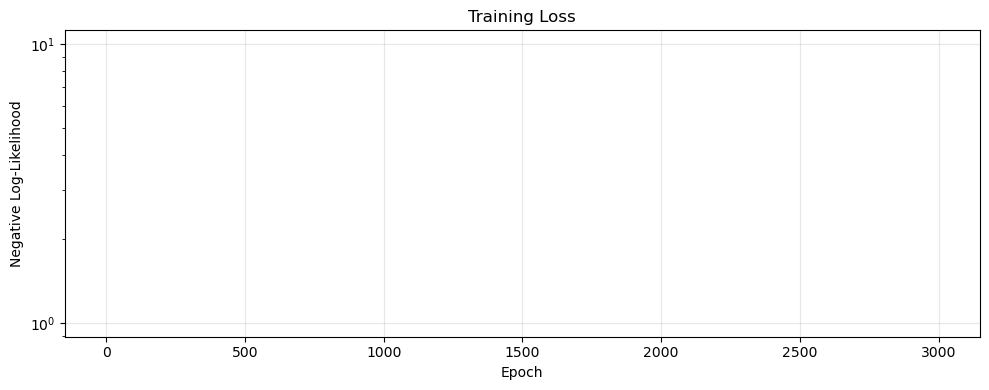

In [ ]:
n_epochs   = 3000
batch_size = 8192
losses     = []

for epoch in range(n_epochs):
    # ── Mini-batch sampling ──
    idx          = torch.randint(0, N_data, (batch_size,), device=device)
    th_batch     = theta_n[idx]
    om_batch     = omega_n[idx]
    om_next_batch = omega_next[idx]

    optimizer.zero_grad()
    loss = nll_loss(th_batch, om_batch, om_next_batch, drift_net, diff_net, dt)
    loss.backward()
    optimizer.step()
    scheduler.step()

    losses.append(loss.item())

    if (epoch + 1) % 500 == 0:
        with torch.no_grad():
            mg_est   = -drift_net(torch.tensor([1.0], device=device),
                                  torch.tensor([0.0], device=device)).item()
            beta_est = -drift_net(torch.tensor([0.0], device=device),
                                  torch.tensor([1.0], device=device)).item()
            alpha_est = diff_net(torch.tensor([0.0], device=device)).item()
        print(f"Epoch {epoch+1:4d} | NLL {loss.item():.4f} | "
              f"mg≈{mg_est:.3f} (true {mg}) | "
              f"β≈{beta_est:.3f} (true {beta}) | "
              f"α≈{alpha_est:.3f} (true {alpha})")

# ── Plot training loss ──
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Compare Learned Drift and Diffusion to Ground Truth

We evaluate the learned drift $n_1$ on a $(\theta,\omega)$ grid and compare to the true linear drift field $-mg\,\theta - \beta\,\omega$.  We also check whether $n_2(\theta)$ has recovered the constant diffusion $\alpha$.

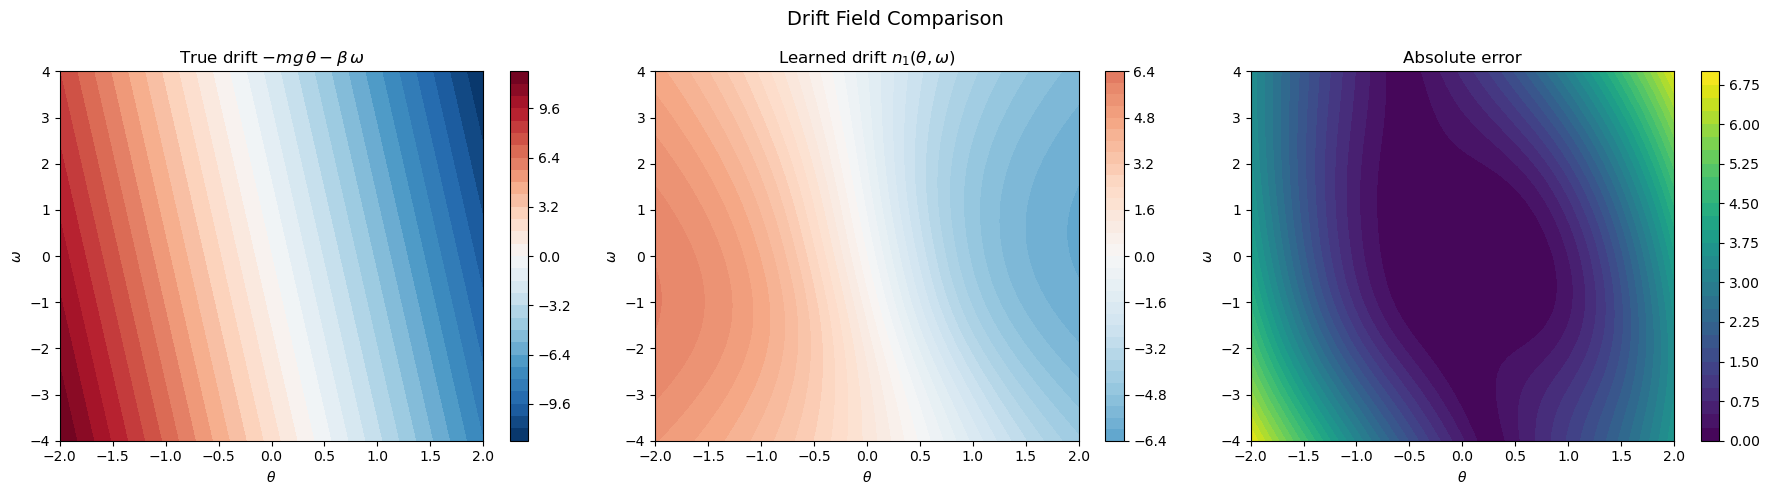


Learned effective params  →  mg ≈ 4.5024 (true 5.0),  β ≈ 0.4608 (true 0.5)


In [9]:
# ── Drift field comparison ──
N_grid = 50
theta_g = torch.linspace(-2, 2, N_grid, device=device)
omega_g = torch.linspace(-4, 4, N_grid, device=device)
TH, OM  = torch.meshgrid(theta_g, omega_g, indexing="ij")

with torch.no_grad():
    learned_drift = drift_net(TH.reshape(-1), OM.reshape(-1)).reshape(N_grid, N_grid)
    true_drift    = -mg * TH - beta * OM

th_np = TH.cpu().numpy()
om_np = OM.cpu().numpy()
ld_np = learned_drift.cpu().numpy()
td_np = true_drift.cpu().numpy()

vmin = min(td_np.min(), ld_np.min())
vmax = max(td_np.max(), ld_np.max())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
im0 = axes[0].contourf(th_np, om_np, td_np, levels=30, cmap="RdBu_r", vmin=vmin, vmax=vmax)
axes[0].set_title(r"True drift $-mg\,\theta - \beta\,\omega$")
axes[0].set_xlabel(r"$\theta$"); axes[0].set_ylabel(r"$\omega$")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(th_np, om_np, ld_np, levels=30, cmap="RdBu_r", vmin=vmin, vmax=vmax)
axes[1].set_title(r"Learned drift $n_1(\theta,\omega)$")
axes[1].set_xlabel(r"$\theta$"); axes[1].set_ylabel(r"$\omega$")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(th_np, om_np, np.abs(td_np - ld_np), levels=30, cmap="viridis")
axes[2].set_title("Absolute error")
axes[2].set_xlabel(r"$\theta$"); axes[2].set_ylabel(r"$\omega$")
plt.colorbar(im2, ax=axes[2])

plt.suptitle("Drift Field Comparison", fontsize=14)
plt.tight_layout()
plt.show()

# ── Print effective parameters ──
with torch.no_grad():
    mg_learned   = -drift_net(torch.tensor([1.0], device=device),
                              torch.tensor([0.0], device=device)).item()
    beta_learned = -drift_net(torch.tensor([0.0], device=device),
                              torch.tensor([1.0], device=device)).item()
print(f"\nLearned effective params  →  mg ≈ {mg_learned:.4f} (true {mg}),  β ≈ {beta_learned:.4f} (true {beta})")

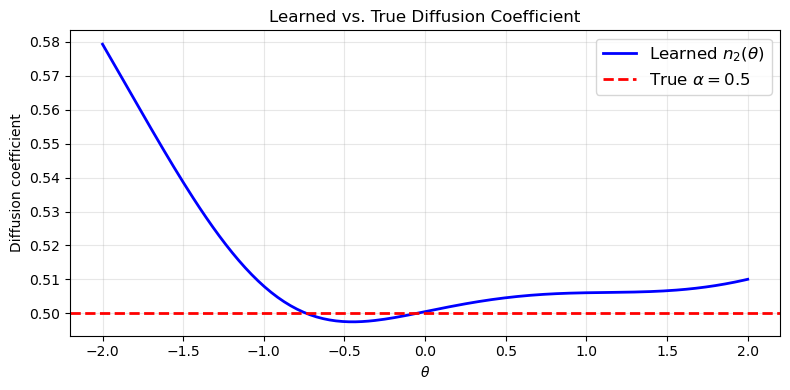

Learned α ≈ 0.5005  (true 0.5)


In [10]:
# ── Diffusion coefficient comparison ──
theta_test = torch.linspace(-2, 2, 200, device=device)
with torch.no_grad():
    learned_diff = diff_net(theta_test).cpu().numpy()

plt.figure(figsize=(8, 4))
plt.plot(theta_test.cpu().numpy(), learned_diff, "b-", linewidth=2,
         label=r"Learned $n_2(\theta)$")
plt.axhline(y=alpha, color="r", linestyle="--", linewidth=2,
            label=rf"True $\alpha = {alpha}$")
plt.xlabel(r"$\theta$")
plt.ylabel("Diffusion coefficient")
plt.title("Learned vs. True Diffusion Coefficient")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

alpha_learned = diff_net(torch.tensor([0.0], device=device)).item()
print(f"Learned α ≈ {alpha_learned:.4f}  (true {alpha})")

## 9. Simulate Trajectories from the Learned Model

We run Euler–Maruyama forward using the **learned** $n_1,n_2$ to generate an ensemble of sample paths.

In [11]:
N_test = 64   # number of realisations from the learned model

theta_pred = torch.zeros(N_test, N_steps + 1, device=device)
omega_pred = torch.zeros(N_test, N_steps + 1, device=device)

# Re-use the same initial conditions as the training data
theta_pred[:, 0] = torch.tensor(theta[:N_test, 0], dtype=torch.float32, device=device)
omega_pred[:, 0] = torch.tensor(omega[:N_test, 0], dtype=torch.float32, device=device)

with torch.no_grad():
    for n in range(N_steps):
        xi    = torch.randn(N_test, device=device)
        drift = drift_net(theta_pred[:, n], omega_pred[:, n])
        diff  = diff_net(theta_pred[:, n])
        theta_pred[:, n+1] = theta_pred[:, n] + omega_pred[:, n] * dt
        omega_pred[:, n+1] = omega_pred[:, n] + drift * dt + diff * np.sqrt(dt) * xi

theta_pred_np = theta_pred.cpu().numpy()
omega_pred_np = omega_pred.cpu().numpy()
print(f"Generated {N_test} learned-model trajectories")

Generated 64 learned-model trajectories


## 10. Overlay Learned vs True Trajectory Statistics

We compare:
1. **Sample paths** — a few individual realisations
2. **Ensemble mean ± std** — statistical envelopes
3. **Phase portraits**
4. **Stationary marginal of $\theta$** — histograms at the final time

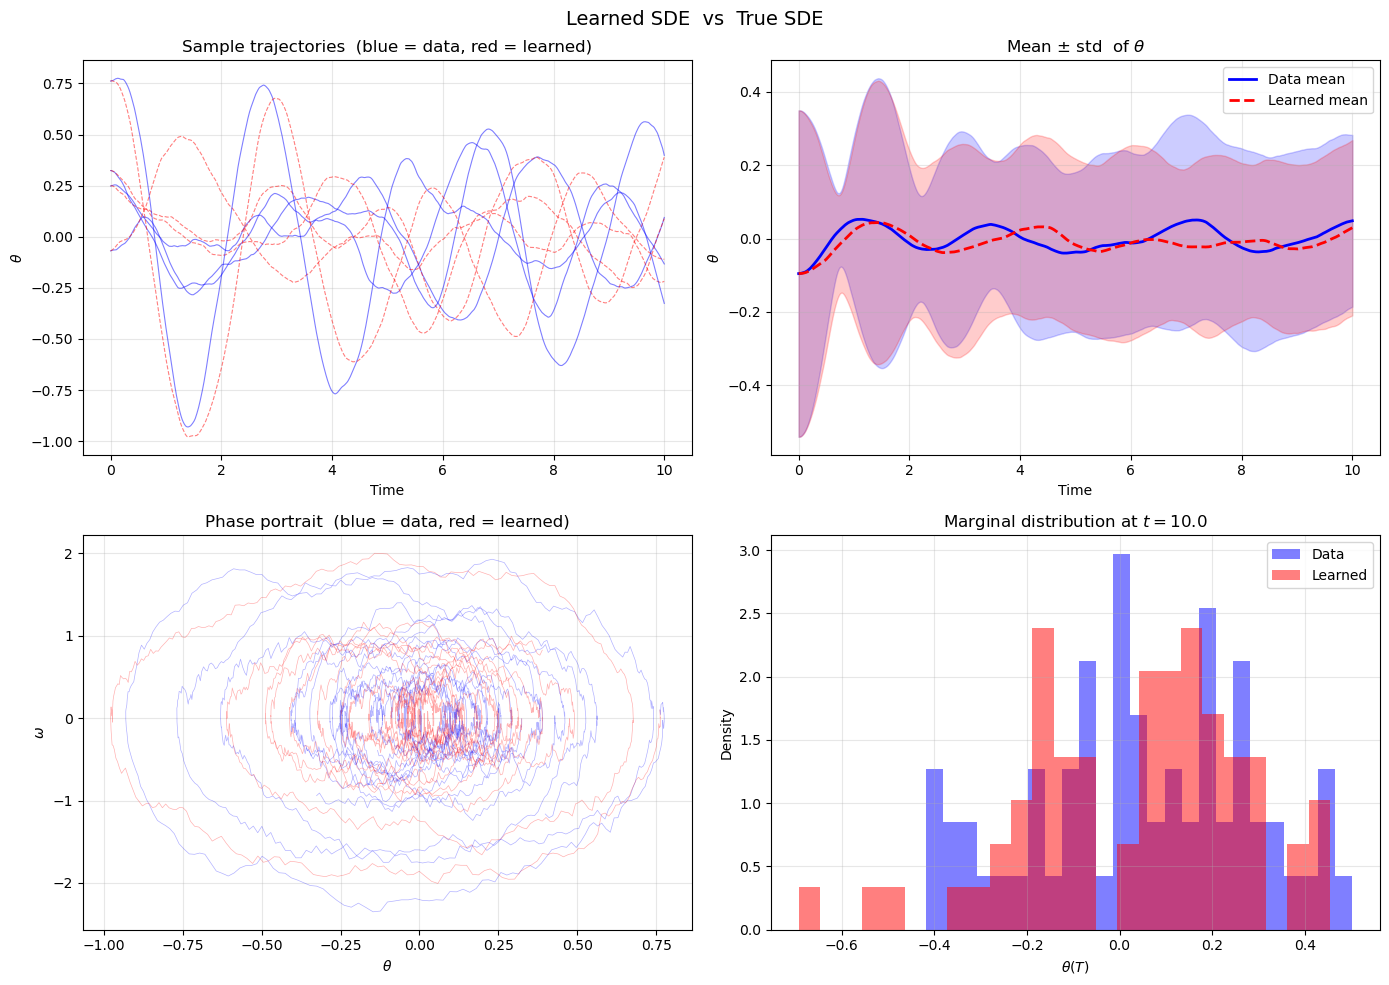

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Sample trajectories
for i in range(4):
    axes[0, 0].plot(t_grid, theta[i],          "b-",  alpha=0.5, lw=0.8)
    axes[0, 0].plot(t_grid, theta_pred_np[i],  "r--", alpha=0.5, lw=0.8)
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel(r"$\theta$")
axes[0, 0].set_title("Sample trajectories  (blue = data, red = learned)")
axes[0, 0].grid(True, alpha=0.3)

# (b) Ensemble mean ± std
data_mean = theta[:N_test].mean(axis=0)
data_std  = theta[:N_test].std(axis=0)
pred_mean = theta_pred_np.mean(axis=0)
pred_std  = theta_pred_np.std(axis=0)

axes[0, 1].plot(t_grid, data_mean, "b-", lw=2, label="Data mean")
axes[0, 1].fill_between(t_grid, data_mean - data_std, data_mean + data_std,
                         alpha=0.2, color="blue")
axes[0, 1].plot(t_grid, pred_mean, "r--", lw=2, label="Learned mean")
axes[0, 1].fill_between(t_grid, pred_mean - pred_std, pred_mean + pred_std,
                         alpha=0.2, color="red")
axes[0, 1].set_xlabel("Time")
axes[0, 1].set_ylabel(r"$\theta$")
axes[0, 1].set_title(r"Mean $\pm$ std  of $\theta$")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# (c) Phase portraits
for i in range(4):
    axes[1, 0].plot(theta[i], omega[i],             "b-", alpha=0.3, lw=0.5)
    axes[1, 0].plot(theta_pred_np[i], omega_pred_np[i], "r-", alpha=0.3, lw=0.5)
axes[1, 0].set_xlabel(r"$\theta$")
axes[1, 0].set_ylabel(r"$\omega$")
axes[1, 0].set_title("Phase portrait  (blue = data, red = learned)")
axes[1, 0].grid(True, alpha=0.3)

# (d) Marginal distribution at final time
axes[1, 1].hist(theta[:, -1],          bins=25, alpha=0.5, density=True,
                color="blue", label="Data")
axes[1, 1].hist(theta_pred_np[:, -1],  bins=25, alpha=0.5, density=True,
                color="red",  label="Learned")
axes[1, 1].set_xlabel(r"$\theta(T)$")
axes[1, 1].set_ylabel("Density")
axes[1, 1].set_title(f"Marginal distribution at $t = {T}$")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("Learned SDE  vs  True SDE", fontsize=14)
plt.tight_layout()
plt.show()